# Stock Price Prediction using HMM, LSTM, ARIMA, and RNN

In this notebook, we will predict stock prices using various methods including Hidden Markov Model (HMM), Long Short-Term Memory (LSTM), AutoRegressive Integrated Moving Average (ARIMA), and Recurrent Neural Network (RNN). We will compare the performance of these models using various error metrics.


In [3]:
# Import necessary libraries for data manipulation, model building, and evaluation
%matplotlib inline
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import math
import scipy.stats as stats

## Load and Prepare Data

In this section, we load the NIFTY 50 data and preprocess it for modeling.


In [27]:
data_csv = pd.read_csv(r"NIFTY 50.csv")
data_csv

,Date,Open,High,Low,Close,Volume,Turnover,P/E,P/B,Div Yield
0,2000-01-03,1482.15,1592.90,1482.15,1592.20,25358322,8.841500e+09,25.91,4.63,0.95
1,2000-01-04,1594.40,1641.95,1594.40,1638.70,38787872,1.973690e+10,26.67,4.76,0.92
2,2000-01-05,1634.55,1635.50,1555.05,1595.80,62153431,3.084790e+10,25.97,4.64,0.95
3,2000-01-06,1595.80,1639.00,1595.80,1617.60,51272875,2.531180e+10,26.32,4.70,0.94
4,2000-01-07,1616.60,1628.25,1597.20,1613.30,54315945,1.914630e+10,26.25,4.69,0.94
...,...,...,...,...,...,...,...,...,...,...
5348,2021-07-01,15755.05,15755.55,15667.05,15680.00,224921644,1.735997e+11,28.26,4.23,1.27
5349,2021-07-02,15705.85,15738.35,15635.95,15722.20,254808999,1.801542e+11,28.33,4.24,1.23
5350,2021-07-05,15793.40,15845.95,15762.05,15834.35,207032153,1.497654e+11,28.53,4.27,1.23
5351,2021-07-06,15813.75,15914.20,15801.00,15818.25,391410742,2.445605e+11,28.50,4.26,1.10


In [32]:

data = data_csv[data_csv.columns[0:5]]
data = data[:5348]

# Convert 'Date' column to datetime type
data['Date'] = pd.to_datetime(data['Date'])

# Set the 'Date' column as the index
data.set_index('Date', inplace=True)

# Resample the data to monthly frequency
obs = data.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})
# Reset the index to have 'Date' as a column again
obs = obs.reset_index()
obs


C:\Users\asker\AppData\Local\Temp\ipykernel_3596\3928841171.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  obs = data.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})


,Date,Open,High,Low,Close
0,2000-01-31,1482.15,1671.15,1482.15,1546.20
1,2000-02-29,1546.20,1818.15,1521.40,1654.80
2,2000-03-31,1661.50,1773.85,1489.10,1528.45
3,2000-04-30,1528.70,1636.95,1311.30,1406.55
4,2000-05-31,1410.00,1436.60,1201.50,1380.45
...,...,...,...,...,...
253,2021-02-28,13758.60,15431.75,13661.75,14529.15
254,2021-03-31,14702.50,15336.30,14264.40,14690.70
255,2021-04-30,14798.40,15044.35,14151.40,14631.10
256,2021-05-31,14481.05,15606.35,14416.25,15582.80


In [31]:
data = obs[:162]
print(data)

        Open     High      Low    Close
0    1482.15  1671.15  1482.15  1546.20
1    1546.20  1818.15  1521.40  1654.80
2    1661.50  1773.85  1489.10  1528.45
3    1528.70  1636.95  1311.30  1406.55
4    1410.00  1436.60  1201.50  1380.45
..       ...      ...      ...      ...
157  6040.95  6052.95  5671.90  5693.05
158  5702.45  5971.20  5604.85  5682.55
159  5697.35  5962.30  5477.20  5930.20
160  5911.40  6229.45  5910.95  5985.95
161  5997.35  6011.00  5566.25  5842.20

[162 rows x 4 columns]


In [22]:
258-162

96

## Hidden Markov Model (HMM)

We will implement the HMM to predict future stock prices.

data:         Open     High      Low    Close
0    1482.15  1671.15  1482.15  1546.20
1    1546.20  1818.15  1521.40  1654.80
2    1661.50  1773.85  1489.10  1528.45
3    1528.70  1636.95  1311.30  1406.55
4    1410.00  1436.60  1201.50  1380.45
..       ...      ...      ...      ...
157  6040.95  6052.95  5671.90  5693.05
158  5702.45  5971.20  5604.85  5682.55
159  5697.35  5962.30  5477.20  5930.20
160  5911.40  6229.45  5910.95  5985.95
161  5997.35  6011.00  5566.25  5842.20

[162 rows x 4 columns]
T=  162
        Open     High      Low    Close
66   2220.45  2332.55  2171.25  2312.30
67   2312.05  2426.65  2294.25  2384.65
68   2384.70  2633.90  2382.90  2601.40
69   2601.00  2669.20  2307.45  2370.95
70   2366.80  2727.05  2366.80  2652.25
..       ...      ...      ...      ...
157  6040.95  6052.95  5671.90  5693.05
158  5702.45  5971.20  5604.85  5682.55
159  5697.35  5962.30  5477.20  5930.20
160  5911.40  6229.45  5910.95  5985.95
161  5997.35  6011.00  5566.25  5842.20

[

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


        Open     High      Low    Close
69   2601.00  2669.20  2307.45  2370.95
70   2366.80  2727.05  2366.80  2652.25
71   2651.60  2857.00  2641.95  2836.55
72   2836.80  3005.10  2783.85  3001.10
73   3001.30  3090.30  2928.10  3074.70
..       ...      ...      ...      ...
160  5911.40  6229.45  5910.95  5985.95
161  5997.35  6011.00  5566.25  5842.20
162  5834.10  6093.35  5675.75  5742.00
163  5776.90  5808.50  5118.85  5471.80
164  5480.25  6142.50  5318.90  5735.30

[96 rows x 4 columns]
        Open     High      Low    Close
70   2366.80  2727.05  2366.80  2652.25
71   2651.60  2857.00  2641.95  2836.55
72   2836.80  3005.10  2783.85  3001.10
73   3001.30  3090.30  2928.10  3074.70
74   3074.60  3433.85  3064.00  3402.55
..       ...      ...      ...      ...
161  5997.35  6011.00  5566.25  5842.20
162  5834.10  6093.35  5675.75  5742.00
163  5776.90  5808.50  5118.85  5471.80
164  5480.25  6142.50  5318.90  5735.30
165  5756.10  6309.05  5700.95  6299.15

[96 rows x 4 col

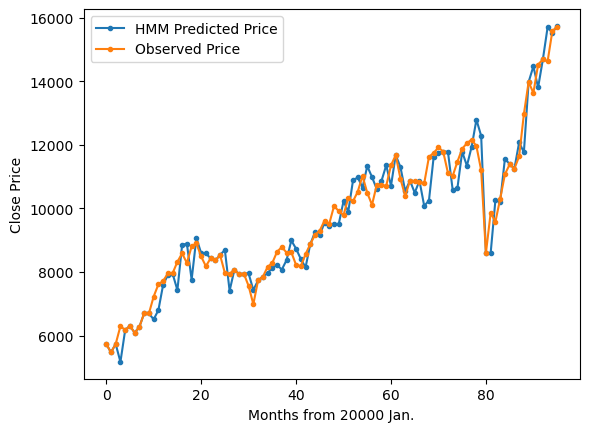

In [30]:
data = data[data.columns[1:5]]
obs = obs[obs.columns[1:5]]
print('data:', data)
# Calculate number of rows and set t
#raining window
T = data.shape[0]
print("T= ", T)

# Define the size of the training window
d = 96
D = 96
hmm_price = []

temp_T = T
first_time = True

# Sliding window approach to predict future prices
while T < temp_T + d:

    # Train HMM on data from T-D+1 to T
    train_data = obs.iloc[T-D:T]
    print(train_data)
    train_data = train_data.dropna()

    # Set the random seed
    np.random.seed(123)

    if(first_time):
      first_time = False
      model = hmm.GaussianHMM(n_components=5)
    else:
      old_model= model
      model = hmm.GaussianHMM(n_components=5, init_params="c")
      model.startprob_ = old_model.startprob_
      model.transmat_ = old_model.transmat_
      model.means_ = old_model.means_

    model.fit(train_data)

    # Calculate original likelihood
    original_likelihood = model.score(train_data)

    # Loop to find new likelihood
    t=T
    min_diff = float('inf')
    min_t = T
    min_likelihood = original_likelihood
    while t-D>  0:
        t = t-1

        train_data = obs.iloc[t-D:t]
        new_likelihood = model.score(train_data)
        if (abs(new_likelihood - original_likelihood))< min_diff:  # Threshold for comparison by choosing that new_likelihood which is minimum
            min_diff = abs(new_likelihood - original_likelihood)
            min_t = t
            min_likelihood = new_likelihood

    # Calculate the predicted close price
    close_price = obs['Close'][T-1] + ((obs['Close'][min_t + 1] - obs['Close'][min_t]) * np.sign(original_likelihood - min_likelihood))

    hmm_price.append(close_price)
    T=T+1

# Print the calculated prices
print("HMM Prices: ")
print(hmm_price)

# Plot the predicted and observed prices
close = []
truncated_obs = obs.iloc[T-d:T]

for i in truncated_obs['Close']:
  close.append(i)

plt.plot(hmm_price,marker='.', label = "HMM Predicted Price")
plt.plot(close,marker = '.', label= "Observed Price")
plt.ylabel("Close Price")
plt.xlabel('Months from 20000 Jan.')
plt.legend()
plt.show()

In [10]:
print(hmm_price)

[ 5742.    5471.8   5735.3   5171.45  6176.1   6304.    6089.5   6276.95
  6704.2   6696.4   6508.95  6802.7   7603.55  7908.75  7943.9   7431.25
  8855.75  8893.8   7756.5   9074.95  8596.3   8583.95  8433.65  8368.5
  8532.85  8697.2   7409.75  8065.8   7935.25  7946.35  7957.45  7433.
  7738.4   7855.3   7961.2   8137.7   8222.6   8076.95  8375.35  8992.55
  8735.65  8411.95  8147.1   8879.6   9255.1   9165.95  9556.2   9446.2
  9498.5   9515.55 10228.2   9900.   10882.   10977.9  10658.35 11331.85
 10989.85 10610.7  10867.   11361.8  10711.1  11680.5  11297.7  10547.65
 10876.75 10493.95 10873.65 10080.9  10248.65 11635.   11759.25 11788.85
 11785.65 10583.15 10644.1  11784.75 11342.6  11947.3  12794.1  12286.1
  8597.75  8594.55 10262.9  10205.95 11564.25 11397.45 11253.55 12078.95
 11766.65 13981.75 14471.9  13809.25 14690.7  15703.5  15525.65 15744.35]


## Plot Predictions

Now, we plot the predictions from all models alongside the actual observed prices.


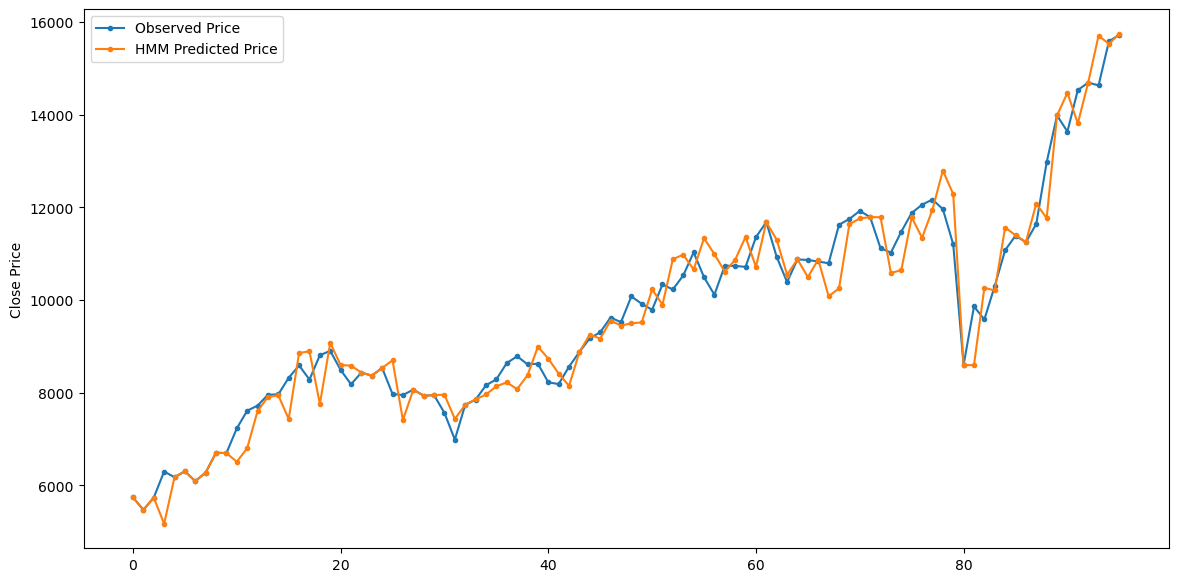

In [6]:
plt.figure(figsize=(14, 7))

# Plot actual prices for the corresponding period
plt.plot(close, marker='.', label='Observed Price')

# Plot HMM predicted prices
plt.plot(hmm_price, marker='.', label='HMM Predicted Price')

plt.ylabel("Close Price")
plt.legend()
plt.show()


-1084.3500000000004 1375.25


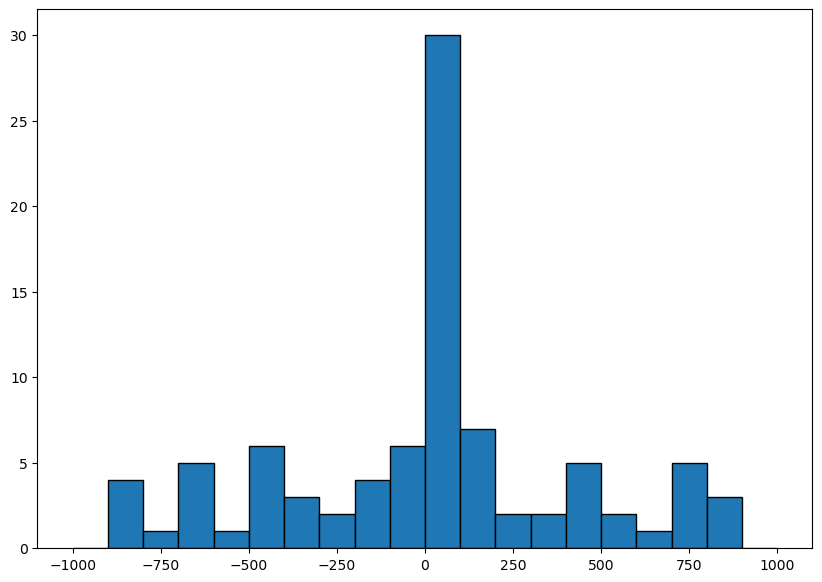

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
close = np.array(close)

hmm_price = np.array(hmm_price)
resids = close - hmm_price
print(np.min(resids), np.max(resids))
xmin = -1000
xmax = 1000
# ax.plot(resids, '.', label='Residuals (Observed - HMM Predicted)')
ax.hist(resids, bins=20, range=(xmin, xmax), edgecolor='black');

## Model Comparison and Efficiency Calculation

In this section, we calculate various error metrics for each model and determine the efficiency of HMM compared to LSTM, ARIMA, and RNN.


In [8]:
# Convert lists to numpy arrays
close = np.array(close)
hmm_price = np.array(hmm_price)

# Ensure all are trimmed to the same length
min_length = min(len(close), len(hmm_price))
print(min_length)
close = close[-min_length:]
hmm_price = hmm_price[-min_length:]

# 1. Absolute Percentage Error (APE)
def ape(real_, pred_):
    APE = 0
    sum = 0
    N = len(real_)
    # Calculate the sum of absolute differences between real and predicted values
    for i in range(1, N):
        sum += (np.abs(real_[i] - pred_[i])) / N

    # Calculate APE as a ratio of the sum to the mean of real values
    APE = sum / (np.mean(real_))

    return APE

ape_hmm = ape(close, hmm_price)

# 2. Average Absolute Error (AAE)
def aae(real_, pred_):
  AAE = 0
  sum = 0
  N = len(real_)
  for i in range(1,N):
    sum += (np.abs(real_[i] - pred_[i]))/N
  AAE = sum
  return AAE

aae_hmm = aae(close, hmm_price)

# 3. Average Relative Percentage Error (ARPE)
def arpe(real_, pred_):

  sum = 0
  N = len(real_)
  for i in range(1,N):
    sum += (np.abs(real_[i] - pred_[i]))/N
  ARPE = sum/N
  return ARPE

arpe_hmm = arpe(close, hmm_price)


# 4. Root Mean Squared Error (RMSE)
def rmse(real_, pred_):
  sum = 0
  N = len(real_)
  for i in range(1,N):
    sum += (np.square(real_[i] - pred_[i]))/N
  RMSE = np.sqrt(sum)
  return RMSE

rmse_hmm = rmse(close, hmm_price)


# 6. Efficiency Calculation
def efficiency(hmm_metric, other_metric):
    return 1 - (hmm_metric / other_metric)


96
